## Example: CO2 Trendline Extraction (NOAA MAUNA LOA CO2)

Note, using the regularization term for our least squares solver, we are able to fit trendlines onto noisy data to describe seasonal trends.

In [70]:
from tutorial_module import TrendFilter
import statsmodels.api as sm


data = sm.datasets.co2.load_pandas().data
data = data.interpolate()
series = data['co2'].dropna()
series = series.tail(365) ## run the last year of data to extract seasonal trendlines

dates = series.index
observed_co2 = series.values

model = TrendFilter(observed_co2, order=2, reg_weight=5.0)

print("Extracting long-term CO2 growth trend...")
trend = model.solve()


Extracting long-term CO2 growth trend...


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

## NOTE: utilized ChatGPT to help develop this visualization plot script
def visualize_trend(dates, observed, trend):
    
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    
    ax1.scatter(dates, observed, color='gray', alpha=0.3, s=15, label="Observed Data (Noise + Seasonality)")
    ax1.plot(dates, trend, color='red', linewidth=3, label="L1 Trend (Order-2)")
    ax1.set_title("L1 Trend Filtering: Signal Extraction", fontsize=16)
    ax1.set_ylabel("CO2 Concentration (ppm)", fontsize=12)
    ax1.legend(loc="upper left")

    
    residuals = observed - trend
    ax2.fill_between(dates, residuals, color='blue', alpha=0.2)
    ax2.plot(dates, residuals, color='blue', linewidth=1, label="Residuals (Seasonality)")
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.set_title("Extracted Residuals: High-Frequency Components", fontsize=16)
    ax2.set_ylabel("Deviation (ppm)", fontsize=12)
    ax2.set_xlabel("Time", fontsize=12)
    ax2.legend(loc="upper left")

    plt.tight_layout()
    plt.show()


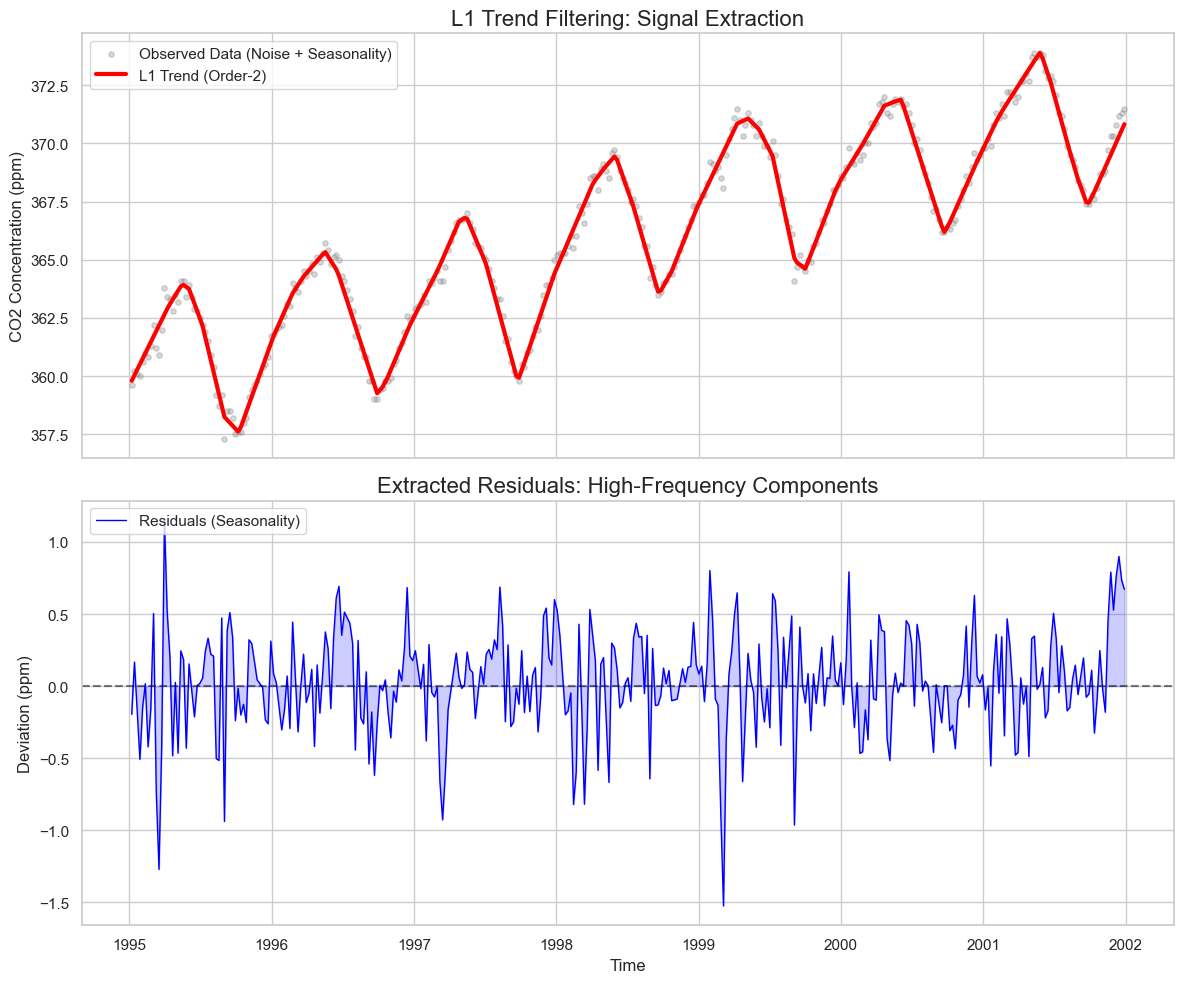

In [72]:
visualize_trend(dates, observed_co2, trend)

## Example 2: Stock Pricing

Following, we can extract approximate stock trends using order 1 for a staircase least squares approximation, or order 2 for a more dynamic line. This evaluates the stocks at a daily level while visually describing trends such as market volatility.

In [73]:
import numpy as np
import pandas as pd
import yfinance as yf # A common DS library for stock data


data = yf.download("NVDA", start="2025-01-01", end="2025-12-12")
prices = data['Close'].values

model = TrendFilter(prices, order=1, reg_weight=5.0)

print("Identifying support and resistance levels...")
levels = model.solve()

print(f"Number of unique price levels detected: {len(np.unique(np.round(levels, 2)))}")

[*********************100%***********************]  1 of 1 completed


Identifying support and resistance levels...
Number of unique price levels detected: 92


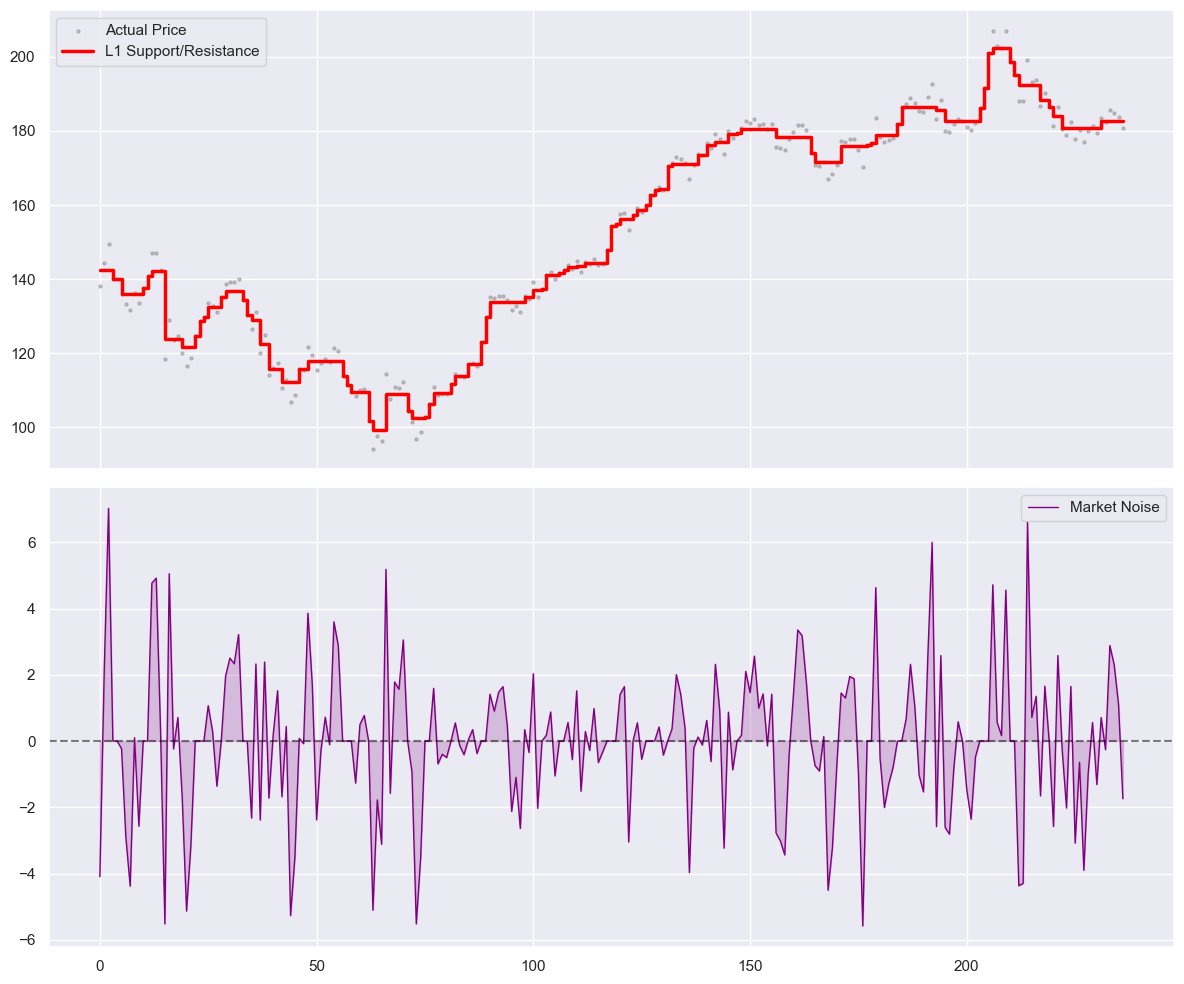

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

## NOTE: Utilized ChatGPT to strengthen visualizations using seaborn
def visualize_stock_trend(dates, prices, levels):
    # Ensure everything is 1D to satisfy Matplotlib
    dates = np.ravel(dates)
    prices = np.ravel(prices)
    levels = np.ravel(levels)
    
    ## calculation of residuals for volatility
    volatility = prices - levels

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # price model fit for trendline
    ax1.scatter(dates, prices, color='gray', alpha=0.4, label="Actual Price", s=5)
    ax1.step(dates, levels, where='post', color="red", linewidth=2.5, label="L1 Support/Resistance")
    ax1.legend()

    # market volatility plot from residuals
    ax2.fill_between(dates, volatility, 0, color='purple', alpha=0.2)
    ax2.plot(dates, volatility, color='purple', linewidth=1, label="Market Noise")
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()


visualize_stock_trend(np.arange(len(prices)), prices, levels)

Running this same code on a different market ticker such as AAPL yields the following

[*********************100%***********************]  1 of 1 completed

Identifying support and resistance levels...


Number of unique price levels detected: 90


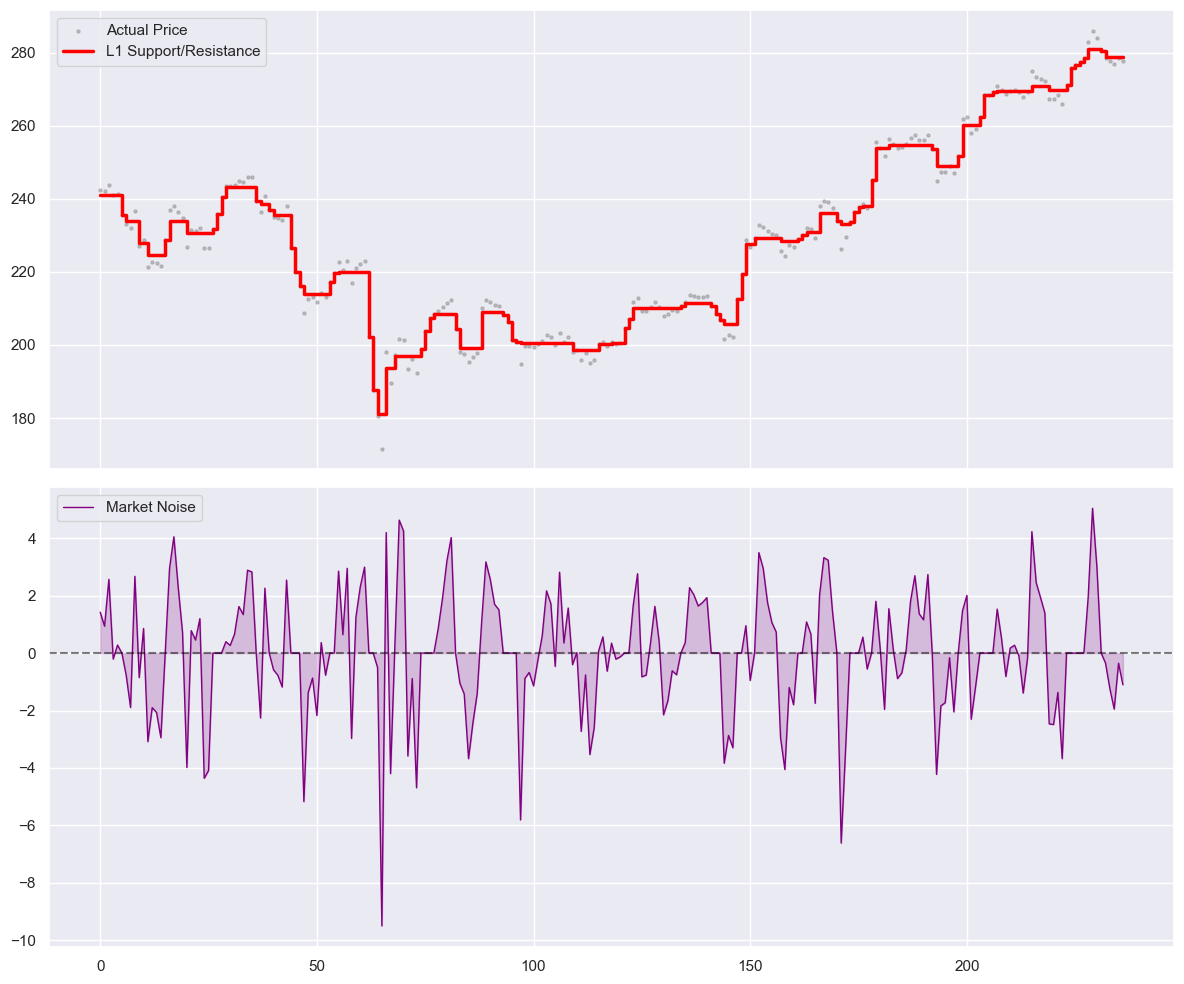

In [75]:
data = yf.download("AAPL", start="2025-01-01", end="2025-12-12")
prices = data['Close'].values

model = TrendFilter(prices, order=1, reg_weight=5.0)

print("Identifying support and resistance levels...")
levels = model.solve()

print(f"Number of unique price levels detected: {len(np.unique(np.round(levels, 2)))}")
visualize_stock_trend(np.arange(len(prices)), prices, levels)

or a competitor like Microsoft for example...

[*********************100%***********************]  1 of 1 completed

Identifying support and resistance levels...


Number of unique price levels detected: 106


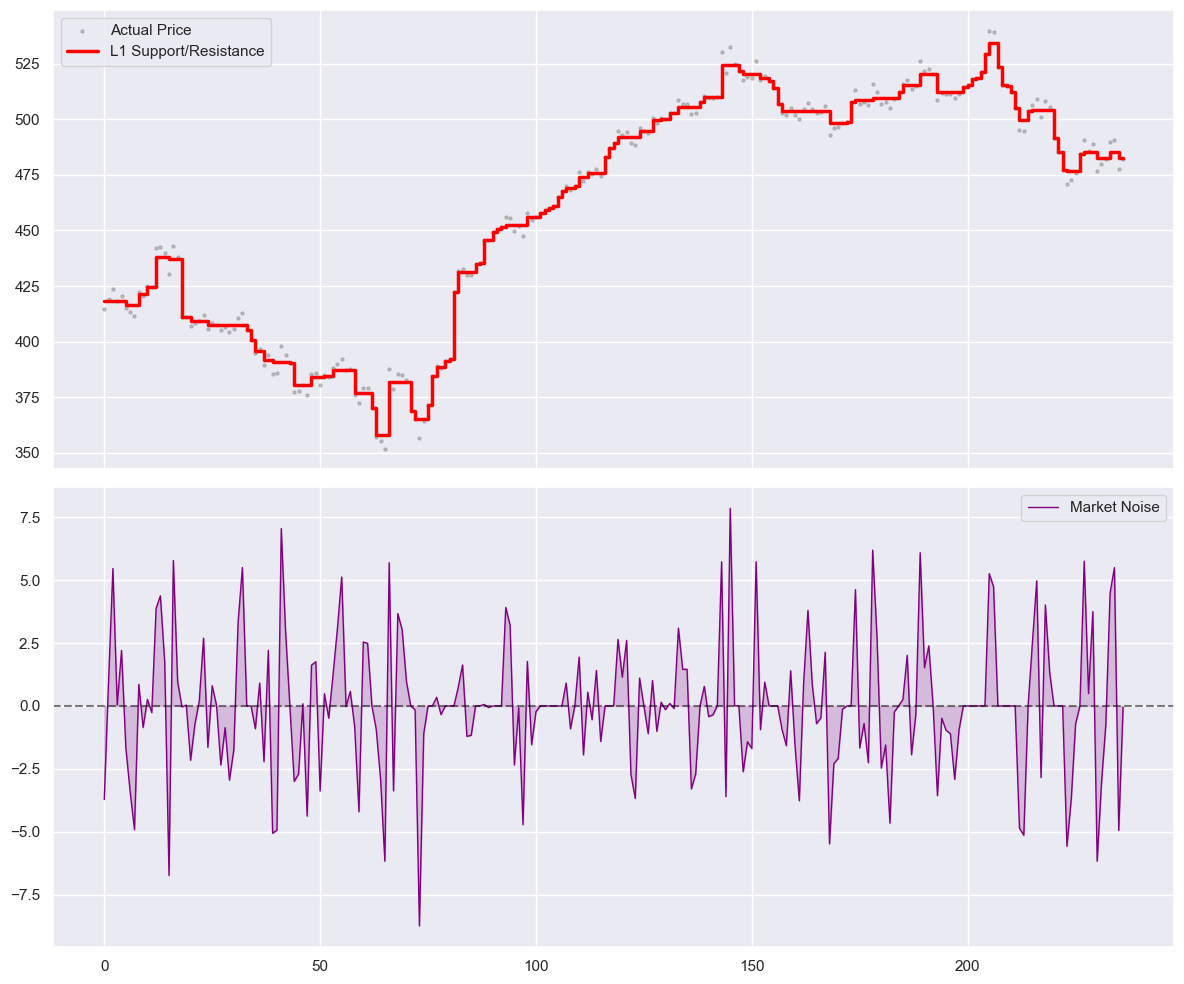

In [76]:
data = yf.download("MSFT", start="2025-01-01", end="2025-12-12")
prices = data['Close'].values

model = TrendFilter(prices, order=1, reg_weight=5.0)

print("Identifying support and resistance levels...")
levels = model.solve()

print(f"Number of unique price levels detected: {len(np.unique(np.round(levels, 2)))}")
visualize_stock_trend(np.arange(len(prices)), prices, levels)